In [2]:
# Esta celda importa librerías para manejo de datos, álgebra y gráficos.
# Sirve para preparar el entorno antes del entrenamiento del modelo.
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para algunas gráficas 3D
%matplotlib inline

In [3]:
# Esta celda define la ruta del dataset local.
# Sirve para reemplazar dependencias de Google Colab en VS Code.
data_path = 'Datos0..csv'
print(f'Archivo a usar: {os.path.abspath(data_path)}')

Archivo a usar: e:\USFX\6to Semestre\Ia\Ejercicios\Datos0..csv


In [4]:
# Esta celda carga el dataset y separa X (features) y y (objetivo).
# Sirve para trabajar con regresión múltiple usando cnt como variable a predecir.
df = pd.read_csv(data_path, sep=';')
target_col = 'cnt'
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].astype(float).values
y = df[target_col].astype(float).values
m = y.size
n = X.shape[1]

print(f'm = {m}, n = {n}')
print('{:>12s}{:>12s}{:>12s}'.format(feature_cols[0], feature_cols[1], 'y(cnt)'))
print('-' * 36)
for i in range(10):
    print('{:12.4f}{:12.4f}{:12.4f}'.format(X[i, 0], X[i, 1], y[i]))

m = 17379, n = 12
      season          yr      y(cnt)
------------------------------------
      1.0000      0.0000     16.0000
      1.0000      0.0000     40.0000
      1.0000      0.0000     32.0000
      1.0000      0.0000     13.0000
      1.0000      0.0000      1.0000
      1.0000      0.0000      1.0000
      1.0000      0.0000      2.0000
      1.0000      0.0000      3.0000
      1.0000      0.0000      8.0000
      1.0000      0.0000     14.0000


In [5]:
# Esta celda normaliza cada feature restando media y dividiendo por desviación estándar.
# Sirve para que el descenso por gradiente converja más rápido y de forma estable.
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1.0
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [6]:
# Esta celda aplica la normalización a X.
# Sirve para obtener X_norm, mu y sigma que luego se usan en entrenamiento e inferencias.
X_norm, mu, sigma = featureNormalize(X)

print('Media calculada (primeras 5):', mu[:5])
print('Desviación estándar (primeras 5):', sigma[:5])
print('Primer registro normalizado:')
print(X_norm[0])

Media calculada (primeras 5): [ 2.50163991  0.50256056  6.53777548 11.54675183  0.02877036]
Desviación estándar (primeras 5): [1.10688629 0.49999344 3.43867678 6.91420616 0.16716047]
Primer registro normalizado:
[-1.3566343  -1.0051343  -1.61043792 -1.67000398 -0.1721122   1.49389084
 -1.46689994 -0.66519285 -1.33464759 -1.0932806   0.9473725  -1.55388851]


In [7]:
# Esta celda añade la columna de unos para el término de sesgo/intersección.
# Sirve para que theta_0 sea aprendido por el modelo.
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [8]:
# Esta celda verifica forma y contenido de la matriz de diseño X.
# Sirve para confirmar que X tiene m filas y n+1 columnas.
print('Shape de X:', X.shape)
print('Primer vector X con sesgo:')
print(X[0])

Shape de X: (17379, 13)
Primer vector X con sesgo:
[ 1.         -1.3566343  -1.0051343  -1.61043792 -1.67000398 -0.1721122
  1.49389084 -1.46689994 -0.66519285 -1.33464759 -1.0932806   0.9473725
 -1.55388851]


In [9]:
# Esta celda define la función de costo para regresión lineal múltiple.
# Sirve para medir el error cuadrático medio escalado del modelo.
def computeCostMulti(X, y, theta):
    m = y.shape[0]
    J = (1 / (2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

In [10]:
# Esta celda define descenso por gradiente para optimizar theta.
# Sirve para minimizar iterativamente el costo del modelo.
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

Costo inicial: 32643.764413
Costo final: 10054.081031
Menor costo observado: 10054.081031
Primeros 5 valores de theta: [1.89463088e+02 2.19658813e+01 4.05322409e+01 3.38725687e-02
 5.30743503e+01]
Predicción para ejemplo 100: real=115.00, predicho=73.94


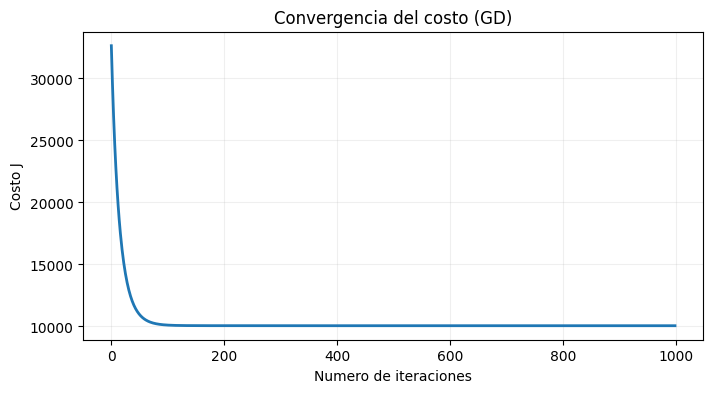

In [11]:
# Esta celda entrena el modelo con descenso por gradiente y grafica convergencia.
# Sirve para obtener theta con el menor costo posible en este enfoque.
alpha = 0.03
num_iters = 1000

theta = np.zeros(n + 1)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo (GD)')
pyplot.grid(alpha=0.2)

print(f'Costo inicial: {J_history[0]:.6f}')
print(f'Costo final: {J_history[-1]:.6f}')
print(f'Menor costo observado: {np.min(J_history):.6f}')
print('Primeros 5 valores de theta:', theta[:5])

idx1 = 100
X_array = np.concatenate(([1.0], X_norm[idx1]))
price = np.dot(X_array, theta)
print(f'Predicción para ejemplo {idx1}: real={y[idx1]:.2f}, predicho={price:.2f}')

In [11]:
# Esta celda prepara un segundo ejemplo para inferencia con GD.
# Sirve para reutilizar el modelo entrenado en otro registro del dataset.
idx2 = 5000
X_array = np.concatenate(([1.0], X_norm[idx2]))

In [12]:
# Esta celda calcula la segunda predicción usando descenso por gradiente.
# Sirve para comparar predicción vs valor real en otro ejemplo.
price = np.dot(X_array, theta)
print(f'Predicción para ejemplo {idx2}: real={y[idx2]:.2f}, predicho={price:.2f}')

Predicción para ejemplo 5000: real=100.00, predicho=114.43


In [13]:
# Esta celda prepara los datos para la ecuación normal.
# Sirve para obtener una solución cerrada y compararla con gradiente.
X_ne = df[feature_cols].astype(float).values
y_ne = df[target_col].astype(float).values
m_ne = y_ne.size
print(f'm para ecuación normal: {m_ne}')
X_ne = np.concatenate([np.ones((m_ne, 1)), X_ne], axis=1)

m para ecuación normal: 17379


In [14]:
# Esta celda define la ecuación normal para estimar theta sin iteraciones.
# Sirve como método alternativo al descenso por gradiente.
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.linalg.pinv(np.dot(X.T, X)), np.dot(X.T, y))
    return theta

In [15]:
# Esta celda calcula theta por ecuación normal y realiza una predicción.
# Sirve para comparar este enfoque con el descenso por gradiente.
theta_ne = normalEqn(X_ne, y_ne)
print('Primeros 5 valores de theta (ecuación normal):', theta_ne[:5])

idx3 = 7000
X_array_ne = X_ne[idx3]
price_ne = np.dot(X_array_ne, theta_ne)
print(f'Predicción (ecuación normal) ejemplo {idx3}: real={y_ne[idx3]:.2f}, predicho={price_ne:.2f}')

Primeros 5 valores de theta (ecuación normal): [-2.57572918e+01  1.98993376e+01  8.10871557e+01 -8.64823317e-03
  7.67059663e+00]
Predicción (ecuación normal) ejemplo 7000: real=285.00, predicho=45.99
